# Escala de Grises con Estrategias Fotográficas

## Objetivos
Aplicar técnicas profesionales de composición visual al convertir imágenes a escala de grises:

1. **Separación Sujeto/Fondo** → Detección de bordes
2. **Reducción de Ruido Visual** → Bilateral filter
3. **Profundidad de Campo** → Blur selectivo
4. **Espacio Negativo** → Áreas vacías resaltadas
5. **Acercamiento/Zoom** → ROI ampliada
6. **Blanco y Negro** → Threshold + contraste

In [29]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline

## Clase Principal: EscalaGrisesEstrategias

In [30]:
class EscalaGrisesEstrategias:
    def __init__(self, ruta_imagen):
        """Inicializa con la imagen de entrada."""
        self.imagen_original = cv2.imread(ruta_imagen)
        if self.imagen_original is None:
            raise ValueError(f"No se pudo cargar la imagen: {ruta_imagen}")
        
        self.nombre_archivo = Path(ruta_imagen).stem
        self.imagen_procesada = None
        
    def convertir_a_grises(self):
        """Conversión básica a escala de grises."""
        return cv2.cvtColor(self.imagen_original, cv2.COLOR_BGR2GRAY)
    
    def visualizar_comparacion(self, titulo="Comparación"):
        """Visualiza imagen original vs procesada."""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
        
        original_rgb = cv2.cvtColor(self.imagen_original, cv2.COLOR_BGR2RGB)
        ax1.imshow(original_rgb)
        ax1.set_title("Original")
        ax1.axis("off")
        
        if self.imagen_procesada is not None:
            ax2.imshow(self.imagen_procesada, cmap="gray")
            ax2.set_title(titulo)
            ax2.axis("off")
        
        plt.suptitle("Escala de Grises - Estrategias Fotográficas", fontsize=14)
        plt.tight_layout()
        plt.show()
    
    def guardar(self, carpeta_salida="../imagenes/procesadas", sufijo=""):
        """Guarda la imagen procesada."""
        if self.imagen_procesada is None:
            print("❌ No hay imagen procesada para guardar")
            return
        
        os.makedirs(carpeta_salida, exist_ok=True)
        
        nombre_salida = f"{self.nombre_archivo}{sufijo}.jpg"
        ruta_salida = os.path.join(carpeta_salida, nombre_salida)
        
        cv2.imwrite(ruta_salida, self.imagen_procesada)
        print(f"✅ Imagen guardada: {ruta_salida}")
        return ruta_salida

print("✓ Clase creada exitosamente")

✓ Clase creada exitosamente


## 1️⃣ Estrategia: Separación Sujeto/Fondo

**Técnica:** Detección de bordes Canny + operaciones morfológicas

**Uso:** Destacar el objeto principal separándolo del fondo

In [31]:
def separacion_sujeto_fondo(self):
    """
    Detecta bordes y resalta el sujeto principal del fondo.
    Utiliza Canny edge detection + morphological operations.
    """
    gris = self.convertir_a_grises()
    
    # Detectar bordes con Canny
    bordes = cv2.Canny(gris, 100, 200)
    
    # Dilatar para conectar bordes fragmentados
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    bordes_dilatados = cv2.dilate(bordes, kernel, iterations=2)
    
    # Mezclar bordes con imagen original para mejor visualización
    resultado = cv2.addWeighted(gris, 0.7, bordes_dilatados, 0.3, 0)
    
    self.imagen_procesada = resultado
    return resultado

# Agregar método a la clase
EscalaGrisesEstrategias.separacion_sujeto_fondo = separacion_sujeto_fondo

## 2️⃣ Estrategia: Reducción de Ruido Visual

**Técnica:** Bilateral Filter

**Ventaja:** Preserva bordes mientras suaviza áreas homogéneas

In [32]:
def reduccion_ruido(self, intensidad=5):
    """
    Reduce el ruido visual aplicando desenfoque bilateral.
    Preserva bordes mientras suaviza áreas homogéneas.
    
    Args:
        intensidad (int): Mayor = más suavizado (5-15 recomendado)
    """
    gris = self.convertir_a_grises()
    
    # Aplicar bilateral filter (preserva bordes)
    resultado = cv2.bilateralFilter(gris, intensidad, 75, 75)
    
    self.imagen_procesada = resultado
    return resultado

EscalaGrisesEstrategias.reduccion_ruido = reduccion_ruido

## 3️⃣ Estrategia: Profundidad de Campo

**Técnica:** Detección de objeto + desenfoque selectivo del fondo

**Efecto:** Simula fotografía con poca profundidad de campo

In [33]:
def profundidad_campo(self, blur_fondo=21):
    """
    Simula efecto de profundidad de campo:
    - Detecta el objeto principal (sujeto)
    - Desenfoca el fondo
    - Mantiene nítido el centro
    
    Args:
        blur_fondo (int): Intensidad del desenfoque del fondo (impar)
    """
    gris = self.convertir_a_grises()
    
    # Detectar área principal con threshold adaptativo
    _, mask = cv2.threshold(gris, 127, 255, cv2.THRESH_BINARY)
    
    # Suavizar máscara
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (50, 50))
    mask_suave = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    
    # Desenfoque el fondo
    if blur_fondo % 2 == 0:
        blur_fondo += 1  # Asegurar que sea impar
    fondo_desenfocado = cv2.GaussianBlur(gris, (blur_fondo, blur_fondo), 0)
    
    # Combinar sujeto nítido + fondo desenfocado
    mask_inv = cv2.bitwise_not(mask_suave)
    resultado = cv2.bitwise_and(gris, gris, mask=mask_suave)
    resultado = cv2.add(resultado, cv2.bitwise_and(fondo_desenfocado, fondo_desenfocado, mask=mask_inv))
    
    self.imagen_procesada = resultado
    return resultado

EscalaGrisesEstrategias.profundidad_campo = profundidad_campo

## 4️⃣ Estrategia: Espacio Negativo

**Técnica:** Detección de áreas de bajo contraste

**Uso:** Resaltar el fondo/vacío en composiciones

In [34]:
def espacio_negativo(self):
    """
    Detecta y resalta el "espacio negativo" (fondo/vacío).
    Útil para composiciones con mucho fondo.
    """
    gris = self.convertir_a_grises()
    
    # Detectar áreas de bajo contraste (espacio negativo)
    laplacian = cv2.Laplacian(gris, cv2.CV_64F)
    laplacian = np.uint8(np.absolute(laplacian))
    
    # Invertir para resaltar el espacio vacío
    espacio_negativo = 255 - laplacian
    
    # Mezclar con imagen original
    resultado = cv2.addWeighted(gris, 0.6, espacio_negativo, 0.4, 0)
    
    self.imagen_procesada = resultado
    return resultado

EscalaGrisesEstrategias.espacio_negativo = espacio_negativo

## 5️⃣ Estrategia: Acercamiento/Zoom

**Técnica:** Recorte de ROI (Region of Interest) + redimensionamiento

**Efecto:** Enfatiza el detalle central eliminando bordes

In [35]:
def acercamiento_roi(self, porcentaje=70):
    """
    Detecta la región de interés (ROI) y hace zoom.
    Recorta el 70% del centro por defecto.
    
    Args:
        porcentaje (int): Porcentaje del área a mantener (1-100)
    """
    gris = self.convertir_a_grises()
    alto, ancho = gris.shape
    
    # Calcular ROI centrada
    factor = porcentaje / 100
    new_alto = int(alto * factor)
    new_ancho = int(ancho * factor)
    
    y_inicio = (alto - new_alto) // 2
    x_inicio = (ancho - new_ancho) // 2
    
    roi = gris[y_inicio:y_inicio+new_alto, x_inicio:x_inicio+new_ancho]
    
    # Redimensionar a tamaño original
    resultado = cv2.resize(roi, (ancho, alto), interpolation=cv2.INTER_LINEAR)
    
    self.imagen_procesada = resultado
    return resultado

EscalaGrisesEstrategias.acercamiento_roi = acercamiento_roi

## 6️⃣ Estrategia: Blanco y Negro con Contraste

**Técnica:** Threshold + CLAHE (Contrast Limited Adaptive Histogram Equalization)

**Efecto:** Conversión a blanco/negro puro con contraste mejorado

In [36]:
def blanco_negro_contraste(self, threshold=127, contraste=1.5):
    """
    Conversión a blanco y negro puro + ajuste de contraste.
    
    Args:
        threshold (int): Valor umbral (0-255)
        contraste (float): Factor de contraste (1.0 = normal, >1 = más contraste)
    """
    gris = self.convertir_a_grises()
    
    # Aplicar threshold para blanco y negro
    _, bn = cv2.threshold(gris, threshold, 255, cv2.THRESH_BINARY)
    
    # Aumentar contraste usando CLAHE
    clahe = cv2.createCLAHE(clipLimit=contraste, tileGridSize=(8, 8))
    resultado = clahe.apply(bn)
    
    self.imagen_procesada = resultado
    return resultado

EscalaGrisesEstrategias.blanco_negro_contraste = blanco_negro_contraste

---
## 🎬 Ejemplo de Uso Interactivo

In [37]:
# Ruta relativa a carpeta de imágenes
carpeta_imagenes = os.path.join("..", "imagenes", "originales")

# Listar imágenes disponibles
if not os.path.exists(carpeta_imagenes):
    print(f"❌ Carpeta no encontrada: {carpeta_imagenes}")
else:
    archivos = [f for f in os.listdir(carpeta_imagenes) if f.lower().endswith(('.jpg', '.png', '.jpeg', '.bmp'))]
    
    if archivos:
        print(f"📁 Imágenes disponibles en {carpeta_imagenes}:")
        for i, archivo in enumerate(archivos, 1):
            print(f"   {i}. {archivo}")
        
        # Seleccionar primera imagen (cambiar índice según sea necesario)
        nombre_imagen = "imagensimplicidadvisual.jpg"
        ruta_imagen = os.path.join(carpeta_imagenes, nombre_imagen)
        ruta_absoluta = os.path.abspath(ruta_imagen)
        
        # Crear procesador
        procesador = EscalaGrisesEstrategias(ruta_imagen)
        print(f"\n✅ Imagen cargada: {nombre_imagen}")
        print(f"   Dimensiones: {procesador.imagen_original.shape}")
    else:
        print(f"❌ No hay imágenes en {carpeta_imagenes}")

📁 Imágenes disponibles en ..\imagenes\originales:
   1. imagencamaraoscura.jpg
   2. imagensimplicidadvisual.jpg

✅ Imagen cargada: imagensimplicidadvisual.jpg
   Dimensiones: (8160, 3768, 3)


### Aplicar Estrategia 1: Separación Sujeto/Fondo

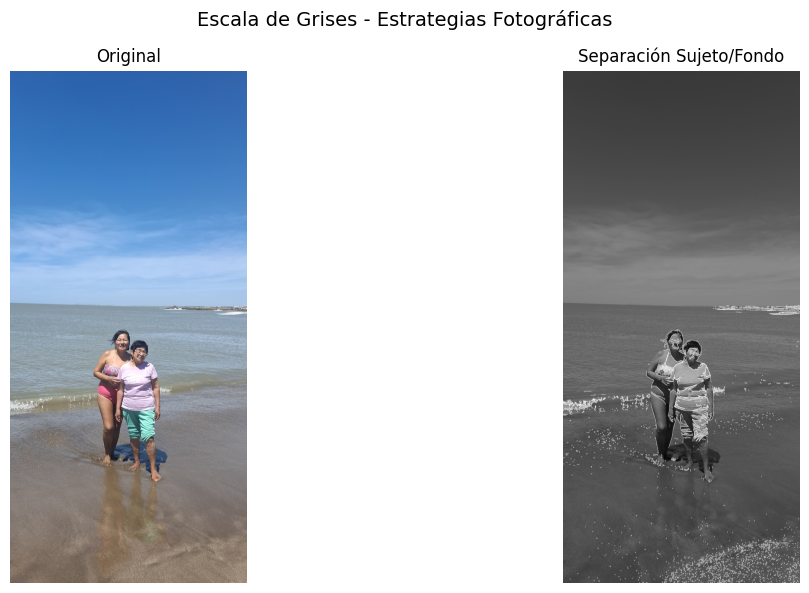

✅ Imagen guardada: ../imagenes/descartes\imagensimplicidadvisual_sujeto_fondo.jpg


'../imagenes/descartes\\imagensimplicidadvisual_sujeto_fondo.jpg'

In [38]:
procesador.separacion_sujeto_fondo()
procesador.visualizar_comparacion("Separación Sujeto/Fondo")
procesador.guardar(carpeta_salida="../imagenes/descartes", sufijo="_sujeto_fondo")

### Aplicar Estrategia 2: Reducción de Ruido

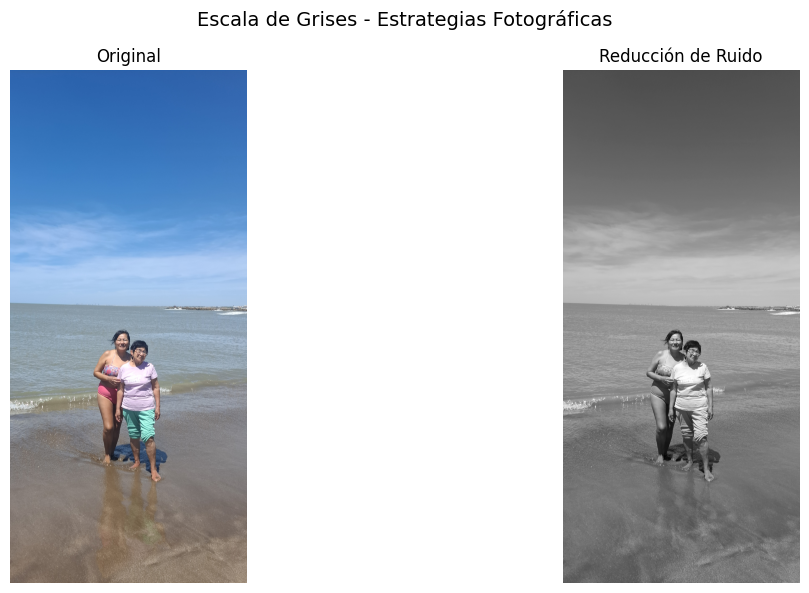

✅ Imagen guardada: ../imagenes/descartes\imagensimplicidadvisual_sin_ruido.jpg


'../imagenes/descartes\\imagensimplicidadvisual_sin_ruido.jpg'

In [39]:
procesador.reduccion_ruido(intensidad=7)
procesador.visualizar_comparacion("Reducción de Ruido")
procesador.guardar(carpeta_salida="../imagenes/descartes", sufijo="_sin_ruido")

### Aplicar Estrategia 3: Profundidad de Campo

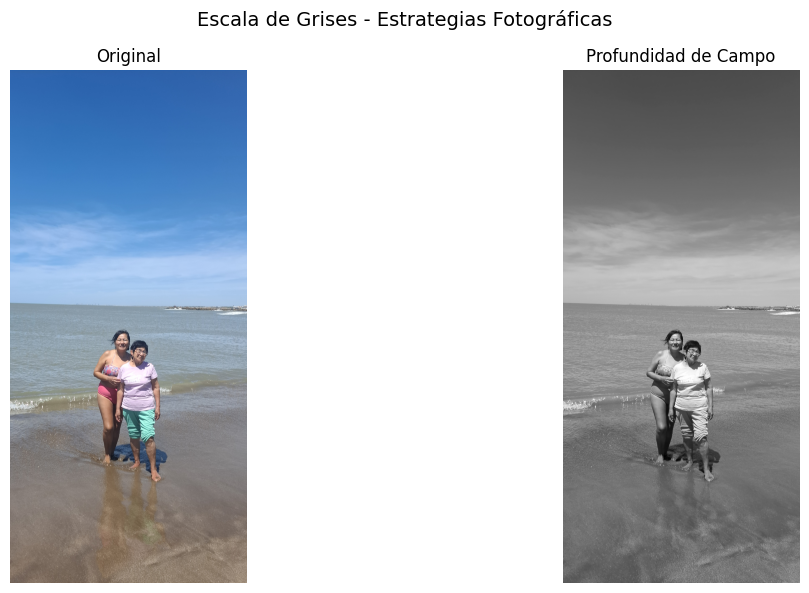

✅ Imagen guardada: ../imagenes/descartes\imagensimplicidadvisual_profundidad.jpg


'../imagenes/descartes\\imagensimplicidadvisual_profundidad.jpg'

In [40]:
procesador.profundidad_campo(blur_fondo=25)
procesador.visualizar_comparacion("Profundidad de Campo")
procesador.guardar(carpeta_salida="../imagenes/descartes", sufijo="_profundidad")

### Aplicar Estrategia 4: Espacio Negativo

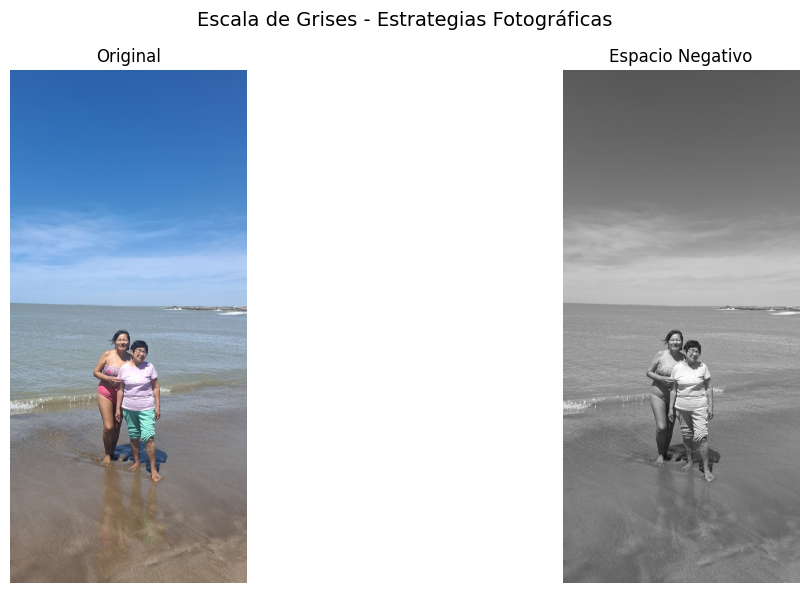

✅ Imagen guardada: ../imagenes/descartes\imagensimplicidadvisual_negativo.jpg


'../imagenes/descartes\\imagensimplicidadvisual_negativo.jpg'

In [41]:
procesador.espacio_negativo()
procesador.visualizar_comparacion("Espacio Negativo")
procesador.guardar(carpeta_salida="../imagenes/descartes", sufijo="_negativo")

### Aplicar Estrategia 5: Acercamiento/Zoom

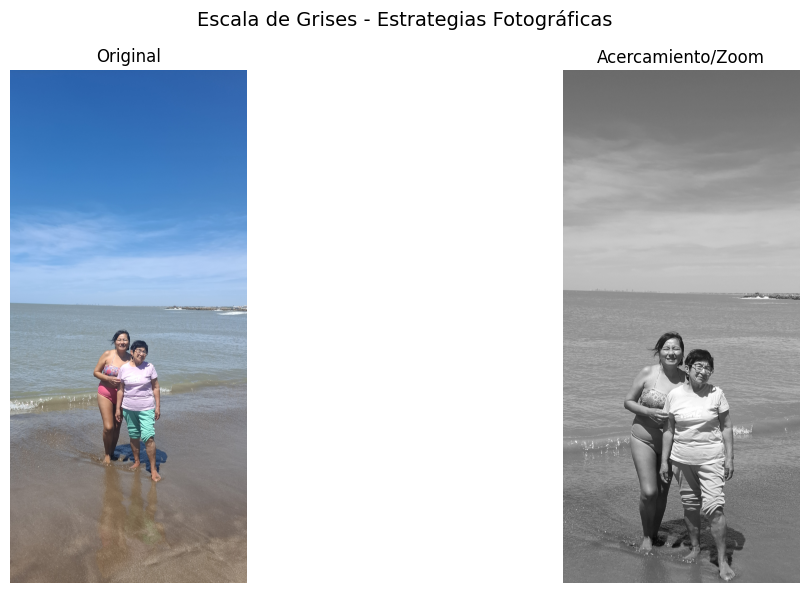

✅ Imagen guardada: ../imagenes/descartes\imagensimplicidadvisual_zoom.jpg


'../imagenes/descartes\\imagensimplicidadvisual_zoom.jpg'

In [ ]:
procesador.acercamiento_roi(porcentaje=61)  
procesador.visualizar_comparacion("Acercamiento/Zoom")
procesador.guardar(carpeta_salida="../imagenes/descartes", sufijo="_zoom")

### Aplicar Estrategia 6: Blanco y Negro

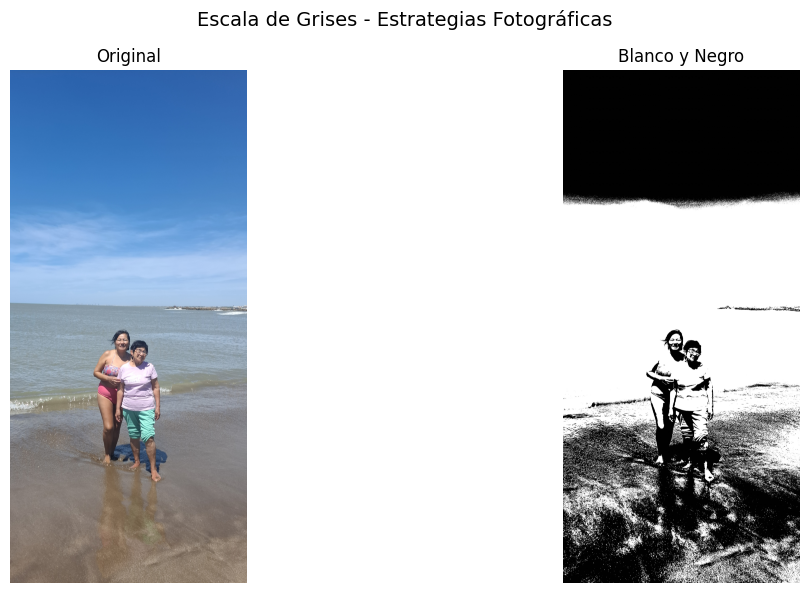

✅ Imagen guardada: ../imagenes/descartes\imagensimplicidadvisual_bn.jpg


'../imagenes/descartes\\imagensimplicidadvisual_bn.jpg'

In [43]:
procesador.blanco_negro_contraste(threshold=127, contraste=2.0)
procesador.visualizar_comparacion("Blanco y Negro")
procesador.guardar(carpeta_salida="../imagenes/descartes", sufijo="_bn")

---
## 📊 Comparación de Todas las Estrategias

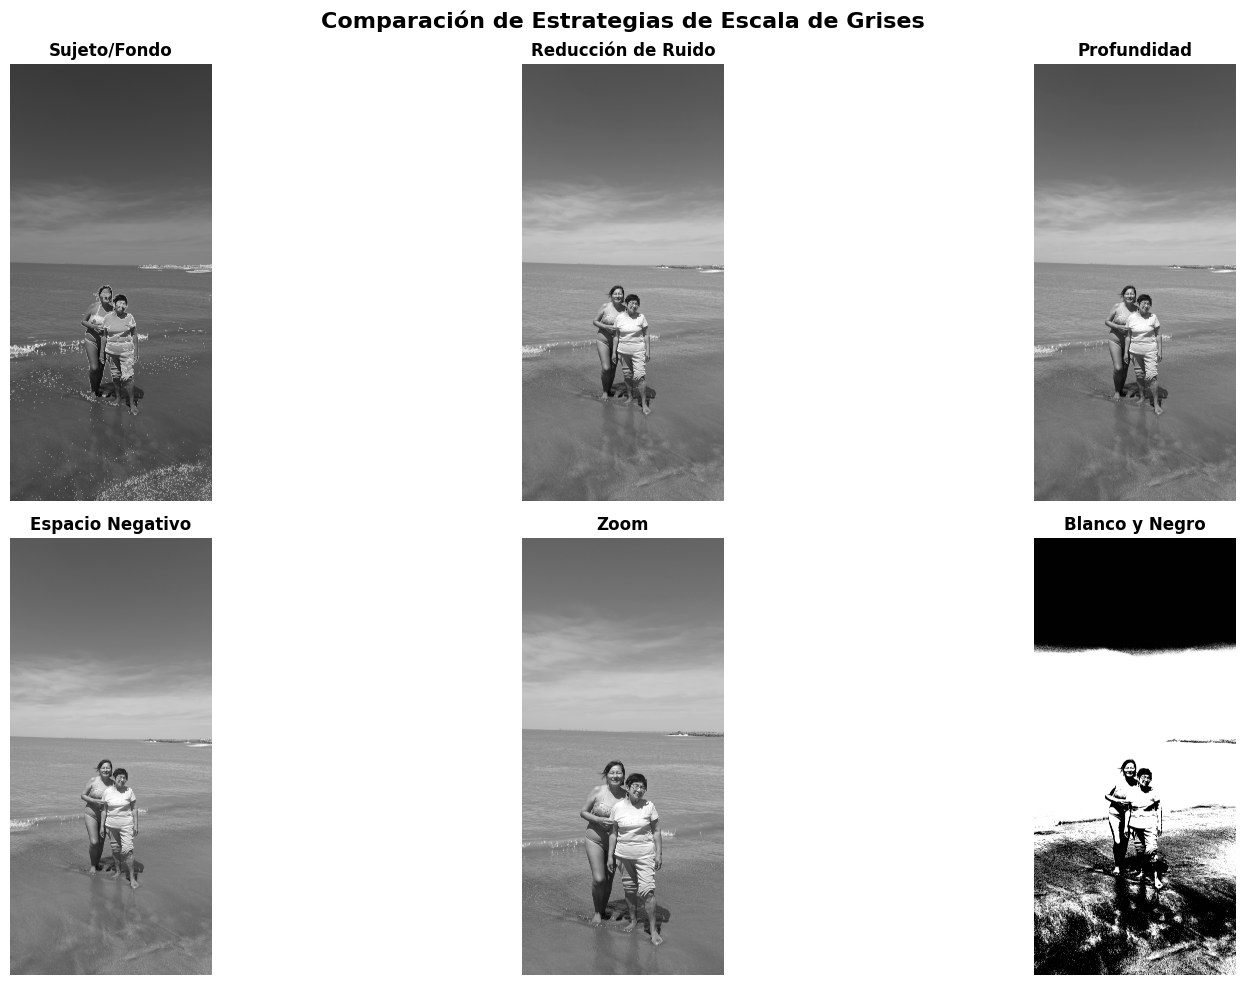

In [44]:
# Procesar con todas las estrategias
estrategias = [
    ("Sujeto/Fondo", procesador.separacion_sujeto_fondo),
    ("Reducción de Ruido", lambda: procesador.reduccion_ruido(5)),
    ("Profundidad", lambda: procesador.profundidad_campo(21)),
    ("Espacio Negativo", procesador.espacio_negativo),
    ("Zoom", lambda: procesador.acercamiento_roi(70)),
    ("Blanco y Negro", lambda: procesador.blanco_negro_contraste(127, 1.5))
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (nombre, funcion) in enumerate(estrategias):
    funcion()
    axes[idx].imshow(procesador.imagen_procesada, cmap="gray")
    axes[idx].set_title(nombre, fontsize=12, fontweight='bold')
    axes[idx].axis("off")

plt.suptitle("Comparación de Estrategias de Escala de Grises", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---

## 💾 Seleccionar Imagen para /procesadas

**Todas las estrategias se guardan en `/descartes`**. Elige una para guardar también en `/procesadas`

In [45]:
# ========== ELIGE ESTRATEGIA A GUARDAR EN /procesadas ==========
print("📋 Estrategias disponibles:")
print("1. Separación Sujeto/Fondo")
print("2. Reducción de Ruido")
print("3. Profundidad de Campo")
print("4. Espacio Negativo")
print("5. Acercamiento/Zoom")
print("6. Blanco y Negro")
print("\n" + "="*60)

# ← EDITA ESTE NÚMERO (1-6) PARA ELEGIR QUÉ ESTRATEGIA GUARDAR
estrategia_elegida = 5

sufijos = {
    1: "_sujeto_fondo",
    2: "_sin_ruido",
    3: "_profundidad",
    4: "_negativo",
    5: "_zoom",
    6: "_bn"
}

nombres = {
    1: "Separación Sujeto/Fondo",
    2: "Reducción de Ruido",
    3: "Profundidad de Campo",
    4: "Espacio Negativo",
    5: "Acercamiento/Zoom",
    6: "Blanco y Negro"
}

if estrategia_elegida in sufijos:
    # Aplicar la estrategia elegida
    estrategias_dict = {
        1: lambda: procesador.separacion_sujeto_fondo(),
        2: lambda: procesador.reduccion_ruido(intensidad=7),
        3: lambda: procesador.profundidad_campo(blur_fondo=25),
        4: lambda: procesador.espacio_negativo(),
        5: lambda: procesador.acercamiento_roi(porcentaje=61),
        6: lambda: procesador.blanco_negro_contraste(threshold=127, contraste=2.0)
    }
    
    estrategias_dict[estrategia_elegida]()
    
    # Guardar en /procesadas
    sufijo = sufijos[estrategia_elegida]
    nombre = nombres[estrategia_elegida]
    procesador.guardar(carpeta_salida="../imagenes/procesadas", sufijo=sufijo)
    print(f"\n✅ '{nombre}' guardada en /procesadas")
    print(f"📁 Todas las otras estrategias están en /descartes")
else:
    print("❌ Número no válido. Debe ser entre 1 y 6")

📋 Estrategias disponibles:
1. Separación Sujeto/Fondo
2. Reducción de Ruido
3. Profundidad de Campo
4. Espacio Negativo
5. Acercamiento/Zoom
6. Blanco y Negro

✅ Imagen guardada: ../imagenes/procesadas\imagensimplicidadvisual_zoom.jpg

✅ 'Acercamiento/Zoom' guardada en /procesadas
📁 Todas las otras estrategias están en /descartes


---

## 📸 Análisis Estrategia 5: Acercamiento/Zoom

### 🎬 Breve Explicación Compositiva

La estrategia de **zoom fotográfico** funciona recortando el **61% del área central** de la imagen y ampliándola al tamaño original. Esto simula el efecto de usar un **lente telefoto**, aproximando el sujeto principal (las dos personas) al primer plano y eliminando el contexto periférico que rodea la escena.

---

### 🚫 ¿Qué Elementos Distraían?

En la composición **original**:
- **Cielo excesivo** en la parte superior (30-40% de la imagen)
- **Agua y arena muy extendidas** en los laterales
- **Horizonte lejano** con pequeños detalles desenfocados
- **Espacio negativo** (vacío) alrededor de los sujetos principales
- Demasiados "bordes muertos" que dispersaban la atención visual

---

### 🗑️ ¿Qué Se Eliminó?

✂️ **Eliminado por el recorte (39% del perímetro):**
- Márgenes de cielo superior e inferior
- Espacios laterales de agua/arena vacía
- Línea del horizonte lejana
- Detalles secundarios del fondo

✓ **Preservado (61% central):**
- Las dos personas (sujeto principal)
- El agua cercana donde están parados
- La zona de interés visual máxima

---

### 🔄 ¿Cómo Cambia la Lectura en Escala de Grises?

| Aspecto | Original (Color) | Zoom (Grises) |
|--------|-----------------|--------------|
| **Enfoque** | Difuso, muchos puntos de atención | Concentrado en los sujetos |
| **Contraste** | Azul cielo vs. piel crea separación cromática | El B/N unifica tonos, las personas destacan por forma |
| **Profundidad** | Cielo y agua crean múltiples planos de color | La proximidad se lee por tamaño y nitidez |
| **Lectura compositiva** | "Personas EN el mar" | "Dos figuras PROTAGONISTAS" |
| **Impacto emocional** | Sereno, contemplativo | Íntimo, directo |

**Efecto clave:** Al eliminar el color y el contexto periférico, la imagen en escala de grises se convierte en un **retrato ambiental enfocado**, donde las formas de los cuerpos y su posición física dominan completamente la composición.

---

✅ **Conclusión:** La estrategia de zoom transforma una imagen "de playa" en una imagen "sobre dos personas en la playa" — cambia el protagonismo visual hacia adentro.